In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split


In [5]:
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [8]:
from sklearn.impute import SimpleImputer


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


In [11]:
import joblib

In [14]:
import kagglehub

path = kagglehub.dataset_download(
    "rikdifos/credit-card-approval-prediction"
)

print("Dataset path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'credit-card-approval-prediction' dataset.
Dataset path: /kaggle/input/credit-card-approval-prediction
Files: ['.nfs00000000b1bd6f8d0000001d', 'credit_record.csv', 'application_record.csv']


In [15]:
application_path = os.path.join(
    path,
    "application_record.csv"
)

In [16]:
credit_path = os.path.join(
    path,
    "credit_record.csv"
)

In [17]:
application_df = pd.read_csv(application_path)
credit_df = pd.read_csv(credit_path)

In [18]:
print("APPLICATION DATA")
display(application_df.head())

APPLICATION DATA


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [19]:
print("\nCREDIT RECORD")
display(credit_df.head())


CREDIT RECORD


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [20]:
print("Application dataset shape:")
print(application_df.shape)

Application dataset shape:
(438557, 18)


In [21]:
print("\nCredit dataset shape:")
print(credit_df.shape)


Credit dataset shape:
(1048575, 3)


In [23]:
application_columns = [
    'ID',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'FLAG_MOBIL',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'OCCUPATION_TYPE',
    'CNT_FAM_MEMBERS'
]
print("Application DataFrame Columns:")
for col in application_columns:
    print(col)

Application DataFrame Columns:
ID
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
CNT_CHILDREN
AMT_INCOME_TOTAL
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
DAYS_BIRTH
DAYS_EMPLOYED
FLAG_MOBIL
FLAG_WORK_PHONE
FLAG_PHONE
FLAG_EMAIL
OCCUPATION_TYPE
CNT_FAM_MEMBERS


In [24]:
credit_columns = [
    'ID',
    'MONTHS_BALANCE',
    'STATUS'
]
print("Credit DataFrame Columns:")
for col in credit_columns:
    print(col)

Credit DataFrame Columns:
ID
MONTHS_BALANCE
STATUS


In [25]:
application_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [26]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [27]:
display(application_df.describe())

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [28]:
display(credit_df.describe())

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [29]:
print(
    credit_df["STATUS"].value_counts()
)

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [30]:
application_missing = (
    application_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(application_missing)

OCCUPATION_TYPE        134203
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
AMT_INCOME_TOTAL            0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
CNT_FAM_MEMBERS             0
dtype: int64


In [31]:
missing_percentage = (
    application_df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percentage)

OCCUPATION_TYPE        30.601039
ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
CNT_CHILDREN            0.000000
FLAG_OWN_REALTY         0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
AMT_INCOME_TOTAL        0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
FLAG_MOBIL              0.000000
DAYS_EMPLOYED           0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
CNT_FAM_MEMBERS         0.000000
dtype: float64


In [32]:
application_df["OCCUPATION_TYPE"] = (
    application_df["OCCUPATION_TYPE"]
    .fillna("Unknown")
)

In [33]:
print(
    credit_df.isnull().sum()
)

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [34]:
print(
    "Application duplicates:",
    application_df.duplicated().sum()
)

print(
    "Credit duplicates:",
    credit_df.duplicated().sum()
)

Application duplicates: 0
Credit duplicates: 0


In [35]:
application_df.drop_duplicates(inplace=True)
credit_df.drop_duplicates(inplace=True)

In [36]:
print(
    "Duplicate application IDs:",
    application_df["ID"].duplicated().sum()
)

Duplicate application IDs: 47


In [37]:
duplicate_ids = application_df[
    application_df["ID"].duplicated(
        keep=False
    )
]

display(duplicate_ids.head(20))

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
421211,7702516,F,N,Y,2,180000.0,Working,Secondary / secondary special,Married,House / apartment,-11753,-1256,1,1,1,0,Sales staff,4.0
421268,7602432,M,N,Y,0,315000.0,Commercial associate,Higher education,Civil marriage,House / apartment,-16627,-1304,1,0,1,0,Drivers,2.0
421349,7602432,F,N,N,0,117000.0,Pensioner,Higher education,Married,House / apartment,-24708,365243,1,0,0,0,Unknown,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,Unknown,3.0
421698,7213374,M,Y,N,0,148500.0,Working,Secondary / secondary special,Married,House / apartment,-9950,-961,1,0,1,0,Laborers,2.0
421726,7052783,M,Y,Y,0,157500.0,Working,Higher education,Married,House / apartment,-13428,-2589,1,0,1,0,Laborers,2.0
421907,7023651,M,Y,N,1,157500.0,Commercial associate,Incomplete higher,Married,House / apartment,-10521,-1457,1,0,0,0,Drivers,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0
422077,7636389,M,N,N,0,135000.0,Commercial associate,Higher education,Married,House / apartment,-9624,-666,1,0,1,0,Core staff,2.0
422119,7052812,F,N,Y,0,135000.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15002,-123,1,0,0,0,Accountants,1.0


In [38]:
application_df = (
    application_df
    .drop_duplicates(
        subset="ID",
        keep="first"
    )
)

In [39]:
print(
    credit_df["STATUS"]
    .value_counts()
)

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [41]:
bad_status = ["2", "3", "4", "5"]

credit_df["BAD_MONTH"] = (
    credit_df["STATUS"]
    .astype(str)
    .isin(bad_status)
    .astype(int)
)

In [42]:
display(
    credit_df[
        ["ID", "STATUS", "BAD_MONTH"]
    ].head(20)
)

,ID,STATUS,BAD_MONTH
0,5001711,X,0
1,5001711,0,0
2,5001711,0,0
3,5001711,0,0
4,5001712,C,0
5,5001712,C,0
6,5001712,C,0
7,5001712,C,0
8,5001712,C,0
9,5001712,C,0


In [43]:
customer_target = (
    credit_df
    .groupby("ID")["BAD_MONTH"]
    .max()
    .reset_index()
)

customer_target.rename(
    columns={
        "BAD_MONTH": "TARGET"
    },
    inplace=True
)

In [44]:
display(customer_target.head())

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [45]:
print(
    customer_target["TARGET"]
    .value_counts()
)

print(
    customer_target["TARGET"]
    .value_counts(normalize=True)
)

TARGET
0    45318
1      667
Name: count, dtype: int64
TARGET
0    0.985495
1    0.014505
Name: proportion, dtype: float64


In [46]:
credit_length = (
    credit_df
    .groupby("ID")
    .agg(
        CREDIT_HISTORY_MONTHS=(
            "MONTHS_BALANCE",
            "count"
        ),
        OLDEST_CREDIT_MONTH=(
            "MONTHS_BALANCE",
            "min"
        ),
        LATEST_CREDIT_MONTH=(
            "MONTHS_BALANCE",
            "max"
        )
    )
    .reset_index()
)

In [47]:
credit_summary = customer_target.merge(
    credit_length,
    on="ID",
    how="left"
)

In [48]:
df = application_df.merge(
    credit_summary,
    on="ID",
    how="inner"
)

In [49]:
print("Merged shape:", df.shape)

display(df.head())

Merged shape: (36457, 22)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,CREDIT_HISTORY_MONTHS,OLDEST_CREDIT_MONTH,LATEST_CREDIT_MONTH
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,0,16,-15,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,0,15,-14,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,0,30,-29,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,5,-4,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,5,-26,-22


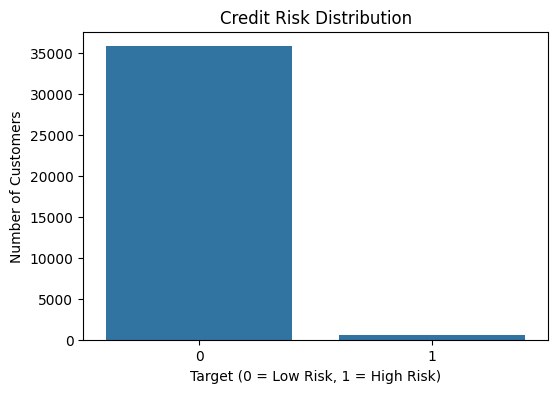

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="TARGET"
)

plt.title(
    "Credit Risk Distribution"
)

plt.xlabel(
    "Target (0 = Low Risk, 1 = High Risk)"
)

plt.ylabel("Number of Customers")

plt.show()

In [51]:
target_percent = (
    df["TARGET"]
    .value_counts(normalize=True)
    * 100
)

print(target_percent)

TARGET
0    98.310338
1     1.689662
Name: proportion, dtype: float64


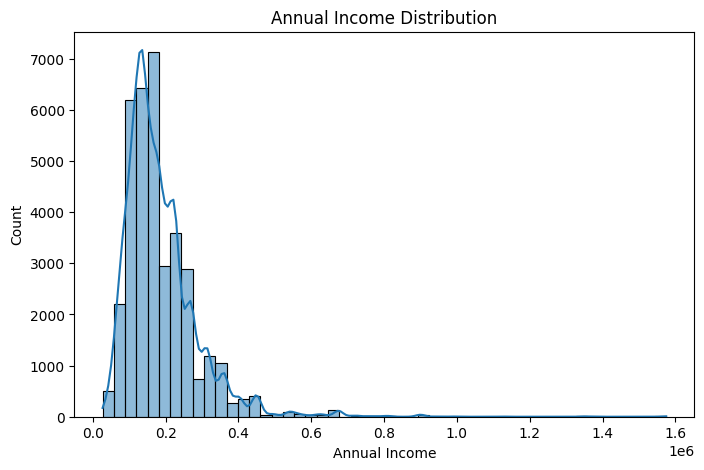

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["AMT_INCOME_TOTAL"],
    bins=50,
    kde=True
)

plt.title(
    "Annual Income Distribution"
)

plt.xlabel(
    "Annual Income"
)

plt.show()

In [53]:
df["AGE"] = (
    -df["DAYS_BIRTH"] / 365.25
)

In [54]:
df["AGE"] = (
    df["AGE"]
    .round()
    .astype(int)
)

In [55]:
df["UNEMPLOYED"] = (
    df["DAYS_EMPLOYED"] > 0
).astype(int)

In [56]:
df["EMPLOYMENT_YEARS"] = np.where(
    df["DAYS_EMPLOYED"] < 0,
    -df["DAYS_EMPLOYED"] / 365.25,
    0
)

In [57]:
df["INCOME_PER_FAMILY_MEMBER"] = (
    df["AMT_INCOME_TOTAL"]
    /
    df["CNT_FAM_MEMBERS"].replace(
        0,
        1
    )
)

In [58]:
df["CHILDREN_RATIO"] = (
    df["CNT_CHILDREN"]
    /
    df["CNT_FAM_MEMBERS"]
    .replace(0, 1)
)

In [59]:
df["HAS_PHONE"] = (
    (
        df["FLAG_PHONE"]
        +
        df["FLAG_WORK_PHONE"]
        +
        df["FLAG_MOBIL"]
    ) > 0
).astype(int)

In [60]:
df.drop(
    columns=[
        "DAYS_BIRTH",
        "DAYS_EMPLOYED"
    ],
    inplace=True
)

In [61]:
df.drop(
    columns=["ID"],
    inplace=True
)

In [62]:
print(df.columns.tolist())

display(df.head())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'CREDIT_HISTORY_MONTHS', 'OLDEST_CREDIT_MONTH', 'LATEST_CREDIT_MONTH', 'AGE', 'UNEMPLOYED', 'EMPLOYMENT_YEARS', 'INCOME_PER_FAMILY_MEMBER', 'CHILDREN_RATIO', 'HAS_PHONE']


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,...,TARGET,CREDIT_HISTORY_MONTHS,OLDEST_CREDIT_MONTH,LATEST_CREDIT_MONTH,AGE,UNEMPLOYED,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,CHILDREN_RATIO,HAS_PHONE
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,...,0,16,-15,0,33,0,12.435318,213750.0,0.0,1
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,...,0,15,-14,0,33,0,12.435318,213750.0,0.0,1
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,...,0,30,-29,0,59,0,3.104723,56250.0,0.0,1
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,...,0,5,-4,0,52,0,8.353183,270000.0,0.0,1
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,...,0,5,-26,-22,52,0,8.353183,270000.0,0.0,1


In [63]:
X = df.drop(
    columns="TARGET"
)

y = df["TARGET"]

In [64]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (36457, 24)
y shape: (36457,)


In [65]:
categorical_features = (
    X.select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)

categorical_features

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE']

In [66]:
numerical_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

numerical_features

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'CREDIT_HISTORY_MONTHS',
 'OLDEST_CREDIT_MONTH',
 'LATEST_CREDIT_MONTH',
 'AGE',
 'UNEMPLOYED',
 'EMPLOYMENT_YEARS',
 'INCOME_PER_FAMILY_MEMBER',
 'CHILDREN_RATIO',
 'HAS_PHONE']

In [67]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [68]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [69]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [70]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

In [71]:
print(
    "Training shape:",
    X_train.shape
)

print(
    "Testing shape:",
    X_test.shape
)

Training shape: (29165, 24)
Testing shape: (7292, 24)


In [72]:
print(
    "Train distribution:"
)

print(
    y_train.value_counts(
        normalize=True
    )
)

print(
    "\nTest distribution:"
)

print(
    y_test.value_counts(
        normalize=True
    )
)

Train distribution:
TARGET
0    0.983096
1    0.016904
Name: proportion, dtype: float64

Test distribution:
TARGET
0    0.983132
1    0.016868
Name: proportion, dtype: float64


In [73]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [74]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'CREDIT_HISTORY_MONTHS',
                                                   'OLDEST_CREDIT_MONTH',
                                                   'LATEST_CREDIT_MONTH', 'AGE',
                                                   'UNE...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [75]:
lr_pred = logistic_model.predict(
    X_test
)

lr_prob = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

In [76]:
decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [77]:
decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'CREDIT_HISTORY_MONTHS',
                                                   'OLDEST_CREDIT_MONTH',
                                                   'LATEST_CREDIT_MONTH', 'AGE',
                                                   'UNE...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=10,
                                        random_state=42))])

In [78]:
dt_pred = (
    decision_tree_model
    .predict(X_test)
)

dt_prob = (
    decision_tree_model
    .predict_proba(X_test)[:, 1]
)

In [80]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [81]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'CREDIT_HISTORY_MONTHS',
                                                   'OLDEST_CREDIT_MONTH',
                                                   'LATEST_CREDIT_MONTH', 'AGE',
                                                   'UNE...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_split=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [82]:
rf_pred = (
    random_forest_model
    .predict(X_test)
)

rf_prob = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

In [83]:
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [84]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

Logistic Regression
Accuracy : 0.7031
Precision: 0.0355
Recall   : 0.6341
F1 Score : 0.0672
ROC-AUC  : 0.7328

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.70      0.82      7169
           1       0.04      0.63      0.07       123

    accuracy                           0.70      7292
   macro avg       0.51      0.67      0.45      7292
weighted avg       0.98      0.70      0.81      7292



In [85]:
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

Decision Tree
Accuracy : 0.7566
Precision: 0.0396
Recall   : 0.5772
F1 Score : 0.0741
ROC-AUC  : 0.7190

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.76      0.86      7169
           1       0.04      0.58      0.07       123

    accuracy                           0.76      7292
   macro avg       0.52      0.67      0.47      7292
weighted avg       0.97      0.76      0.85      7292



In [86]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Random Forest
Accuracy : 0.9680
Precision: 0.1726
Recall   : 0.2358
F1 Score : 0.1993
ROC-AUC  : 0.7989

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.17      0.24      0.20       123

    accuracy                           0.97      7292
   macro avg       0.58      0.61      0.59      7292
weighted avg       0.97      0.97      0.97      7292



In [87]:
def plot_confusion(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(5, 4)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()

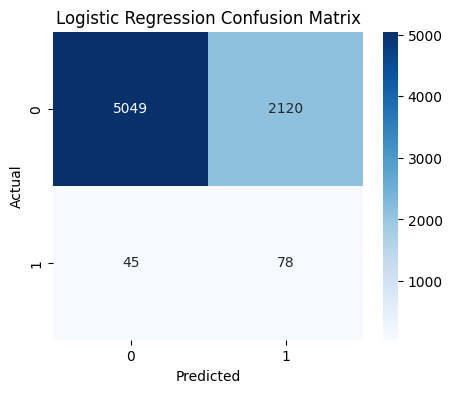

In [88]:
plot_confusion(
    y_test,
    lr_pred,
    "Logistic Regression Confusion Matrix"
)

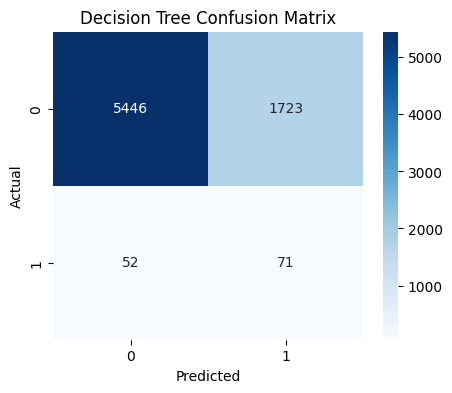

In [89]:
plot_confusion(
    y_test,
    dt_pred,
    "Decision Tree Confusion Matrix"
)

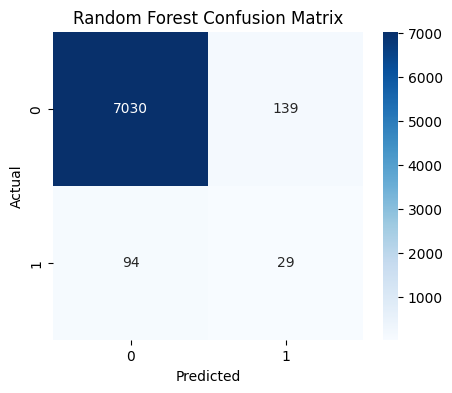

In [90]:
plot_confusion(
    y_test,
    rf_pred,
    "Random Forest Confusion Matrix"
)

<Figure size 800x600 with 0 Axes>

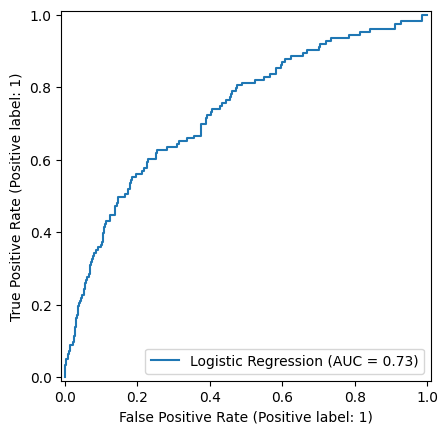

In [91]:
plt.figure(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

plt.show()

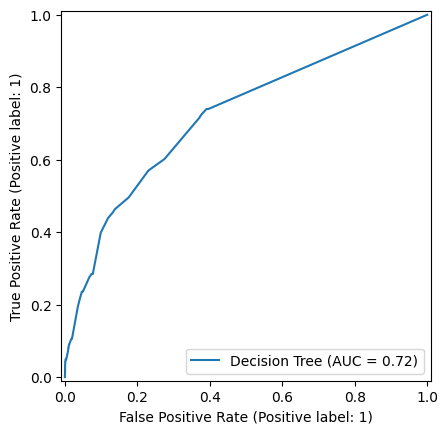

In [92]:
RocCurveDisplay.from_predictions(
    y_test,
    dt_prob,
    name="Decision Tree"
)

plt.show()

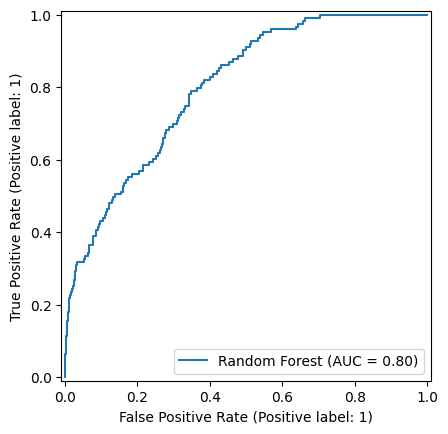

In [93]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.show()

In [94]:
results_df = pd.DataFrame(
    [
        lr_results,
        dt_results,
        rf_results
    ]
)

In [95]:
display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7031,0.0355,0.6341,0.0672,0.7328
1,Decision Tree,0.7566,0.0396,0.5772,0.0741,0.7190
2,Random Forest,0.9680,0.1726,0.2358,0.1993,0.7989


In [96]:
results_df = (
    results_df
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.9680,0.1726,0.2358,0.1993,0.7989
0,Logistic Regression,0.7031,0.0355,0.6341,0.0672,0.7328
1,Decision Tree,0.7566,0.0396,0.5772,0.0741,0.7190


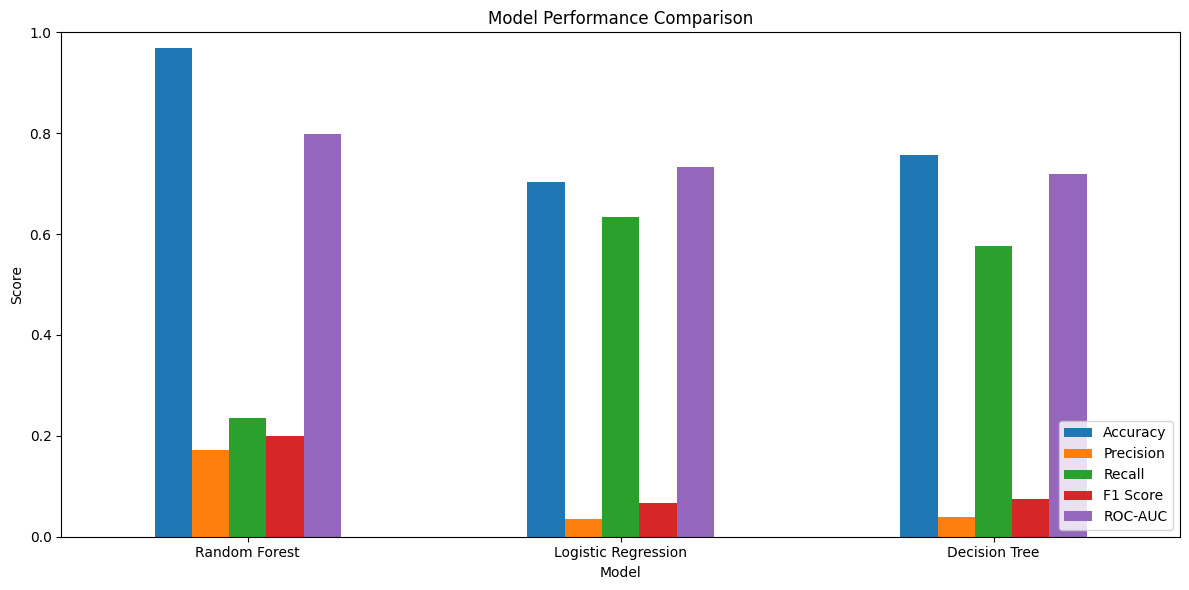

In [97]:
comparison_plot = (
    results_df
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ]
)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()

In [98]:
best_model_name = (
    results_df
    .iloc[0]["Model"]
)

print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


In [99]:
models = {
    "Logistic Regression":
        logistic_model,

    "Decision Tree":
        decision_tree_model,

    "Random Forest":
        random_forest_model
}

best_model = models[
    best_model_name
]

In [100]:
models = {
    "Logistic Regression":
        logistic_model,

    "Decision Tree":
        decision_tree_model,

    "Random Forest":
        random_forest_model
}

best_model = models[
    best_model_name
]

In [101]:
display(
    results_df.iloc[[0]]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.968047,0.172619,0.235772,0.199313,0.798855


In [102]:
joblib.dump(
    best_model,
    "credit_scoring_model.joblib"
)

['credit_scoring_model.joblib']

In [103]:
print(
    "Model saved successfully!"
)

Model saved successfully!


In [104]:
loaded_model = joblib.load(
    "credit_scoring_model.joblib"
)

In [105]:
test_predictions = (
    loaded_model
    .predict(X_test.head())
)

print(
    test_predictions
)

[0 0 0 0 0]


In [106]:
sample_applicant = (
    X_test.iloc[[0]]
)

display(sample_applicant)

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,...,CNT_FAM_MEMBERS,CREDIT_HISTORY_MONTHS,OLDEST_CREDIT_MONTH,LATEST_CREDIT_MONTH,AGE,UNEMPLOYED,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,CHILDREN_RATIO,HAS_PHONE
17085,F,N,Y,0,144000.0,Pensioner,Secondary / secondary special,Married,House / apartment,1,...,2.0,7,-6,0,64,1,0.0,72000.0,0.0,1


In [108]:
prediction = (
    loaded_model
    .predict(sample_applicant)[0]
)

probability = (
    loaded_model
    .predict_proba(
        sample_applicant
    )[0][1]
)

In [109]:
if prediction == 1:

    print(
        "Prediction: HIGH CREDIT RISK"
    )

else:

    print(
        "Prediction: LOW CREDIT RISK"
    )

print(
    f"Risk Probability: "
    f"{probability:.2%}"
)

Prediction: LOW CREDIT RISK
Risk Probability: 11.71%
